The goal of this project is to analyze TikTok engagement patterns and investigate how video/account characteristics relate to user interaction metrics such as views, likes, comments and shares.

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import seaborn as sns

DF_PATH = Path("../data/tiktok_dataset.csv")
df = pd.read_csv(DF_PATH)

In [25]:
# look at the df
df.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,...,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,...,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,...,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,...,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,...,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,...,56167.0,34987.0,4110.0,547.0,152.0


## Cleaning

In [26]:
# shape
df.shape

(19382, 12)

In [27]:
# set df options
pd.set_option("display.max_columns", 10)
pd.set_option("display.max_rows", 1000)

In [28]:
# set # column as index
df.set_index("#", inplace=True)

In [29]:
# clean columns
df.columns = df.columns.str.replace("_", " ").str.title()

In [30]:
# drop columns
df.drop(["Video Id", "Video Transcription Text"], axis=1, inplace=True)
# drop NaN values and duplicates
df.dropna(inplace=True)
df.drop_duplicates(inplace=True, keep="first")

In [31]:
# check max and min values to decide best data types for numerical columns
max_video_duration = df["Video Duration Sec"].max()

for num_col in df.select_dtypes("number"):
    print(f"Max. {num_col}: {df[num_col].max()} | Min. {num_col}: {df[num_col].min()}")

Max. Video Duration Sec: 60 | Min. Video Duration Sec: 5
Max. Video View Count: 999817.0 | Min. Video View Count: 20.0
Max. Video Like Count: 657830.0 | Min. Video Like Count: 0.0
Max. Video Share Count: 256130.0 | Min. Video Share Count: 0.0
Max. Video Download Count: 14994.0 | Min. Video Download Count: 0.0
Max. Video Comment Count: 9599.0 | Min. Video Comment Count: 0.0


In [32]:
# change data types
df = df.astype({"Video Duration Sec": "int8" , "Video View Count": "int32", "Video Like Count": "int32", "Video Share Count": "int32", 
                "Video Download Count": "int16", "Video Comment Count": "int16"})

In [33]:
# change str to category
df["Author Ban Status"] = df["Author Ban Status"].astype("category")
df["Claim Status"] = df["Claim Status"].astype("category")
df["Verified Status"] = df["Verified Status"].astype("category")

In [34]:
# check data types
df.dtypes

Claim Status            category
Video Duration Sec          int8
Verified Status         category
Author Ban Status       category
Video View Count           int32
Video Like Count           int32
Video Share Count          int32
Video Download Count       int16
Video Comment Count        int16
dtype: object

In [35]:
# check final df
df.head()

,Claim Status,Video Duration Sec,Verified Status,Author Ban Status,Video View Count,Video Like Count,Video Share Count,Video Download Count,Video Comment Count
#,,,,,,,,,
1,claim,59,not verified,under review,343296,19425,241,1,0
2,claim,32,not verified,active,140877,77355,19034,1161,684
3,claim,31,not verified,active,902185,97690,2858,833,329
4,claim,25,not verified,active,437506,239954,34812,1234,584
5,claim,19,not verified,active,56167,34987,4110,547,152


## Exploratory Data Analysis

In [36]:
# summary statistics
summaryStats = df.describe(include="number").round(2)
summaryStats.index = summaryStats.index.str.capitalize()
summaryStats

,Video Duration Sec,Video View Count,Video Like Count,Video Share Count,Video Download Count,Video Comment Count
Count,19084.00,19084.00,19084.00,19084.00,19084.00,19084.00
Mean,32.42,254708.56,84304.64,16735.25,1049.43,349.31
Std,16.23,322893.28,133420.55,32036.17,2004.30,799.64
Min,5.00,20.00,0.00,0.00,0.00,0.00
25%,18.00,4942.50,810.75,115.00,7.00,1.00
50%,32.00,9954.50,3403.50,717.00,46.00,9.00
75%,47.00,504327.00,125020.00,18222.00,1156.25,292.00
Max,60.00,999817.00,657830.00,256130.00,14994.00,9599.00


### Do longer / shorter claim videos get more likes per second? (active/under review)

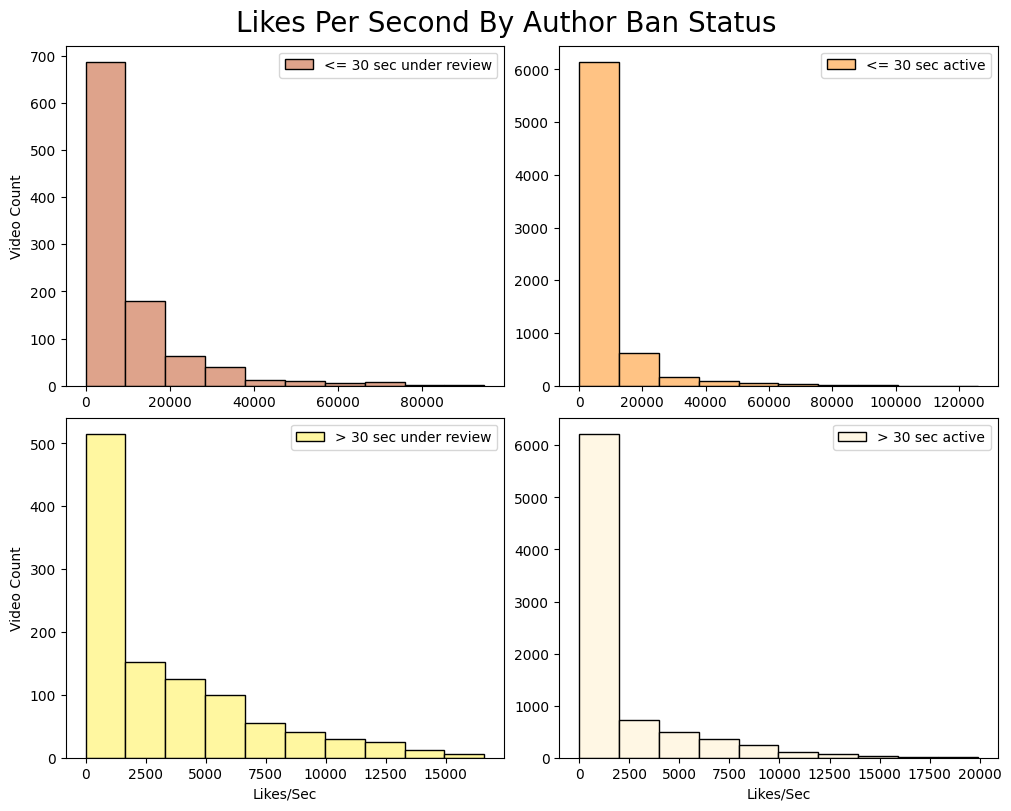

In [37]:
df["Likes Per Second"] = df["Video Like Count"] / df["Video Duration Sec"]

videoDurationLess30SecLikesPerSecUnderReview = df[(df["Video Duration Sec"] <= 30) & (df["Author Ban Status"] == "under review")]["Likes Per Second"].values
videoDurationLess30SecLikesPerSecActive = df[(df["Video Duration Sec"] <= 30) & (df["Author Ban Status"] == "active")]["Likes Per Second"].values

videoDurationMore30SecLikesPerSecUnderReview = df[(df["Video Duration Sec"] > 30) & (df["Author Ban Status"] == "under review")]["Likes Per Second"].values
videoDurationMore30SecLikesPerSecActive = df[(df["Video Duration Sec"] > 30) & (df["Author Ban Status"] == "active")]["Likes Per Second"].values

fig, axes = plt.subplots(nrows=2, ncols=2, constrained_layout=True, figsize=(10, 8))

axes[0, 0].hist(videoDurationLess30SecLikesPerSecUnderReview, label="<= 30 sec under review",
                histtype="bar", color="#dea38b", edgecolor="black")
axes[0, 0].legend()
axes[0, 0].set_ylabel("Video Count")

axes[0, 1].hist(videoDurationLess30SecLikesPerSecActive, label="<= 30 sec active", color="#ffc384", edgecolor="black")
axes[0, 1].legend()

axes[1, 0].hist(videoDurationMore30SecLikesPerSecUnderReview, label="> 30 sec under review", color="#fff7a0", edgecolor="black")
axes[1, 0].legend()
axes[1, 0].set_xlabel("Likes/Sec")
axes[1, 0].set_ylabel("Video Count")

axes[1, 1].hist(videoDurationMore30SecLikesPerSecActive, label="> 30 sec active", color="#fff7e4", edgecolor="black")
axes[1, 1].legend()
axes[1, 1].set_xlabel("Likes/Sec")

plt.suptitle("Likes Per Second By Author Ban Status", fontsize=20)
plt.savefig("../images/likes_per_second_by_author_ban_status.png", bbox_inches="tight", dpi=300)
plt.show()

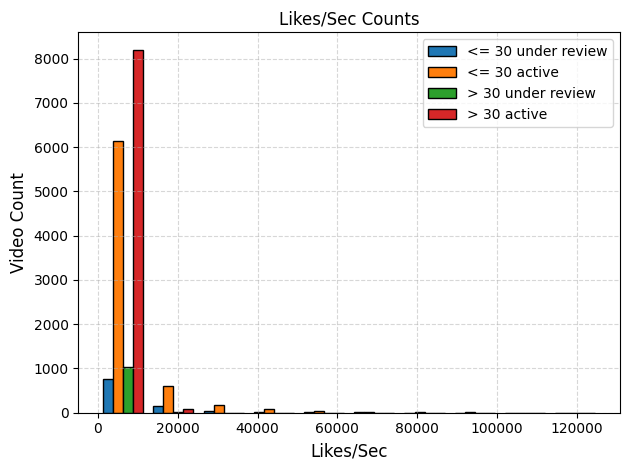

In [38]:

# in a single chart
xMulti = [videoDurationLess30SecLikesPerSecUnderReview, videoDurationLess30SecLikesPerSecActive,
          videoDurationMore30SecLikesPerSecUnderReview, videoDurationMore30SecLikesPerSecActive]
labels = ["<= 30 under review", "<= 30 active", "> 30 under review", "> 30 active"]

plt.hist(xMulti, histtype="bar", label=labels, edgecolor="black")
plt.xlabel("Likes/Sec", fontsize=12)
plt.ylabel("Video Count", fontsize=12)
plt.title("Likes/Sec Counts")
plt.tight_layout()
plt.legend()
plt.grid(True, alpha=0.5, linestyle="--")
plt.savefig("../images/likes_per_second_counts.png", bbox_inches="tight", dpi=300)
plt.show()

In [39]:
# check unique claim statuses
df["Claim Status"].unique()

['claim', 'opinion']
Categories (2, str): ['claim', 'opinion']

### Distribution of video duration per sec

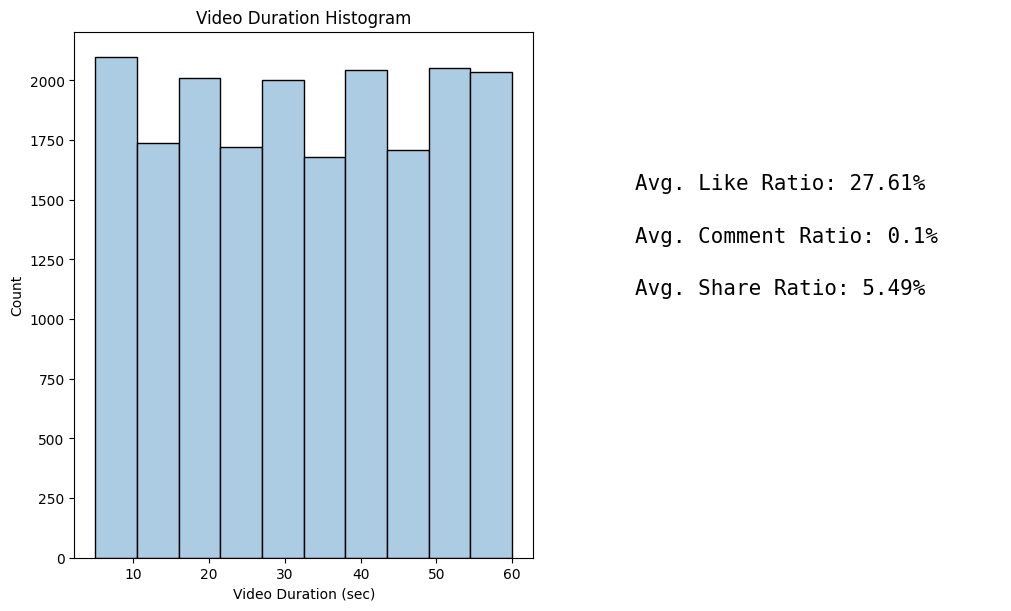

In [40]:
# like_ratio = likes / views
# comment_ratio = comments / views
# share_ratio = shares / views
videoDurations = df["Video Duration Sec"].values
meanLikeRatio = ((df["Video Like Count"].values / df["Video View Count"].values) * 100).mean()
meanCommentRatioPerc = ((df["Video Comment Count"].values / df["Video View Count"].values) * 100).mean()
meanShareRatioPerc = ((df["Video Share Count"] / df["Video View Count"].values) * 100).mean()

fig, axes = plt.subplots(nrows=1, ncols=2, constrained_layout=True,
                         figsize=(10, 6))

axes[0].hist(videoDurations, align="mid", bins=10, edgecolor="black", color="#accce4")
axes[0].set_xlabel("Video Duration (sec)", color="black")
axes[0].set_ylabel("Count", color="black")
axes[0].tick_params(axis="both", labelcolor="black")
axes[0].set_title("Video Duration Histogram")

axes[1].axis("off")
axes[1].text(x=0.2, y=0.7, s=f"Avg. Like Ratio: {np.round(meanLikeRatio, 2)}%", fontsize=15, color="black", fontfamily="monospace")
axes[1].text(x=0.2, y=0.6, s=f"Avg. Comment Ratio: {np.round(meanCommentRatioPerc, 2)}%", fontsize=15, color="black", fontfamily="monospace")
axes[1].text(x=0.2, y=0.5, s=f"Avg. Share Ratio: {np.round(meanShareRatioPerc, 2)}%", fontsize=15, color="black", fontfamily="monospace")
plt.savefig("../images/video_duration_histogram.png", bbox_inches="tight", dpi=300)

### Average engagement (views, likes, comments) per claim.

In [41]:
# check percentages of dataset first
df["Claim Status"].value_counts(normalize=True)

Claim Status
claim      0.503458
opinion    0.496542
Name: proportion, dtype: float64

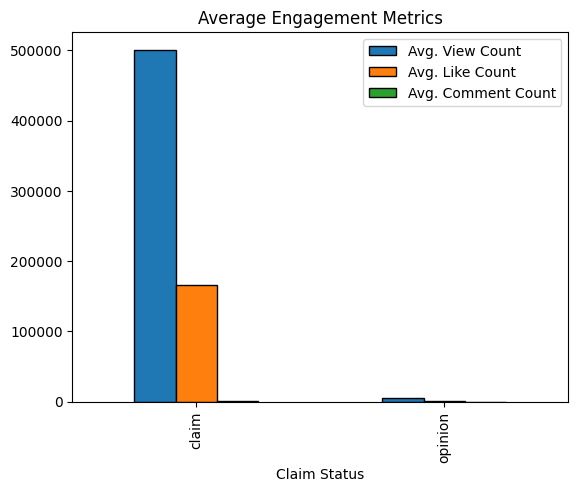

In [42]:
metrics = df.groupby("Claim Status").agg({"Video View Count": "mean", "Video Like Count": "mean", "Video Comment Count": "mean"})
metrics.rename(columns={"Video View Count": "Avg. View Count", "Video Like Count": "Avg. Like Count", "Video Comment Count": "Avg. Comment Count"}, inplace=True)
metrics.plot.bar(edgecolor="black", title="Average Engagement Metrics")
plt.savefig("../images/average_engagement_metrics.png", bbox_inches="tight", dpi=300)

In [43]:
# look at metrics
metrics

,Avg. View Count,Avg. Like Count,Avg. Comment Count
Claim Status,,,
claim,501029.452748,166373.331182,691.164863
opinion,4956.432250,1092.729844,2.697446


### Boxplots of engagement grouped by verified status

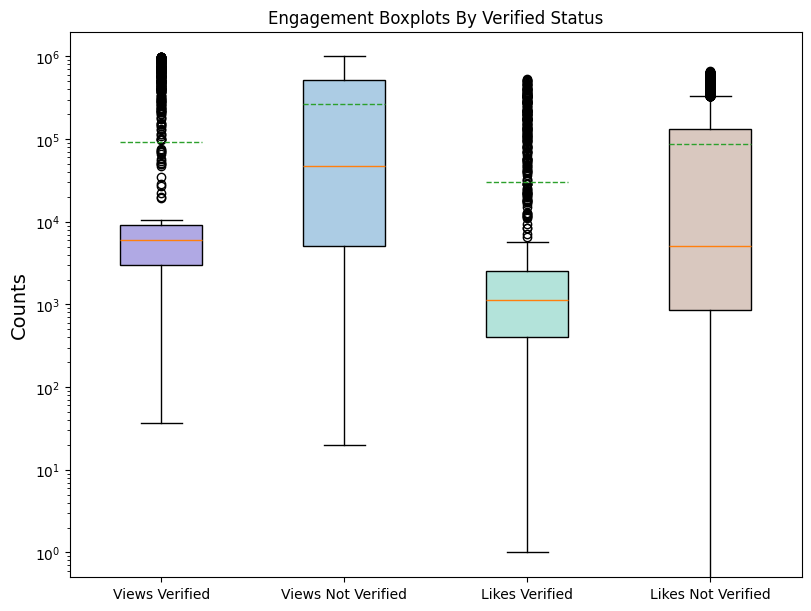

In [44]:
colors = ["#b0a9e4", "#accce4", "#b3e3da", "#d9c8bf"]
labels = ["Views Verified", "Views Not Verified", "Likes Verified",
          "Likes Not Verified"]

viewCountsVerified = df.groupby("Verified Status").get_group("verified")["Video View Count"].values
viewCountsNotVerified = df.groupby("Verified Status").get_group("not verified")["Video View Count"].values

likeCountsVerified = df.groupby("Verified Status").get_group("verified")["Video Like Count"].values
likeCountsNotVerified = df.groupby("Verified Status").get_group("not verified")["Video Like Count"].values

fig, axes = plt.subplots(nrows=1, ncols=1, constrained_layout=True, figsize=(8, 6))

bplot = axes.boxplot([viewCountsVerified, viewCountsNotVerified, likeCountsVerified,
              likeCountsNotVerified], tick_labels=labels, patch_artist=True,
             showmeans=True, meanline=True, orientation="vertical")

axes.set_yscale("log")
axes.set_ylabel("Counts", fontsize=14, color="black")
axes.tick_params(axis="both", labelcolor="black", labelsize=10,
                 rotation=0)
axes.set_title("Engagement Boxplots By Verified Status")

for patch, color in zip(bplot["boxes"], colors):
  patch.set_facecolor(color)
plt.savefig("../images/engagement_boxplots_by_verified_status.png", bbox_inches="tight", dpi=300)

### Numerical Correlations

Text(0.5, 1.0, 'Correlation Heatmap')

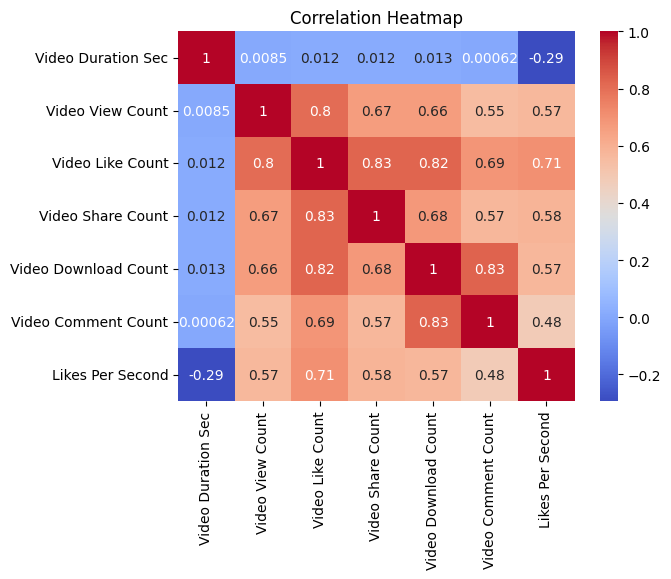

In [45]:
numeric_corrs = df.select_dtypes(include="number").corr(method="pearson")

sns.heatmap(numeric_corrs, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")

## Machine Learning

### Linear Regression Model: predicting video like count based on views

R2 Training Set: 0.651318620871344
R2 Test Set: 0.628890044915658
Mean Sq. Error: 6499448806.07363
Mean Abs. Error: 43561.354293265984


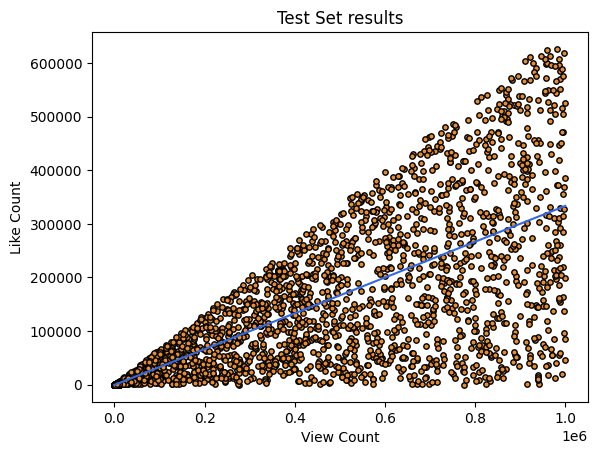

In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

X = df[["Video View Count"]]
y =  df["Video Like Count"]

xTrain, xTest, yTrain, yTest = train_test_split(X, y, test_size=0.2, random_state=42)

# create the model
model = LinearRegression()
model.fit(xTrain, yTrain)

yPred = model.predict(xTest)

# metrics
rSqTrain = model.score(xTrain, yTrain)
rSqTest = model.score(xTest, yTest)
print(f"R2 Training Set: {rSqTrain}")
print(f"R2 Test Set: {rSqTest}")
print(f"Mean Sq. Error: {mean_squared_error(yTest, yPred)}")
print(f"Mean Abs. Error: {mean_absolute_error(yTest, yPred)}")

# plot results (training set)
"""
plt.scatter(xTrain, yTrain, color="#E68D32")
plt.plot(xTrain, model.predict(xTrain), color="#3268E6")
plt.title("Training Set results")
plt.xlabel("View Count")
plt.ylabel("Like Count")
plt.show()
"""

# sort xTrain before plotting because it isn't sorted
xSorted = np.sort(xTrain.values.flatten())
xSortedDf = pd.DataFrame(xSorted, columns=["Video View Count"])
ySortedPred = model.predict(xSortedDf)

# plot results (test set)
plt.scatter(xTest, yTest, color="#E68D32", edgecolor="black", s=15)
plt.plot(xSorted, ySortedPred, color="#3268E6")
plt.title("Test Set results")
plt.xlabel("View Count")
plt.ylabel("Like Count")
plt.show()

### Residuals Plot

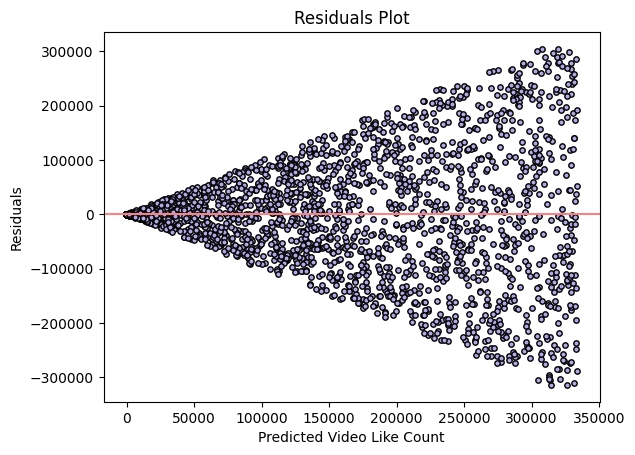

In [47]:
residuals = yTest - yPred

plt.scatter(yPred, residuals, edgecolor="black", color="#b0a9e4", s=15)
plt.axhline(y=0, color="#f98284")
plt.title("Residuals Plot")
plt.xlabel("Predicted Video Like Count")
plt.ylabel("Residuals")
plt.savefig("../images/residuals_plot.png", bbox_inches="tight", dpi=300)

## Exploratory Data Analysis Conclusions

1.	Tiktok videos of active accounts that last <= 30 seconds get the most likes per second. Surprisingly, videos that last the same but whose creators’ account is under review perform decently well, with some even approaching 40k likes per second.
2.	Though some videos get more than 80k likes per second, the vast majority of videos get ≈10-20k likes per second.
3.	Video duration for all videos range from a few seconds to 60. Some metrics to mention, according to the data, are:
-	Average like ratio: 27.61%
-	Average comment ratio: 0.1%
-	Average share ratio: 5.49%
4.	The data is split ≈50% claim and ≈50% opinion, in terms of claim status. Though the size is almost the same, videos categorized as claims have substantially higher average views, likes and comments than videos categorized as opinions. The difference isn’t small and it’s worth noting. 
For example, avg. view count for “claim” videos is ≈500k while the one for “opinion” videos is ≈5k. This large gap suggests that claim-based content may generate significantly more engagement than opinion-based content.
5.	The engagement distributions are strongly right-skewed, with most videos receiving relatively moderate engagement while a small number achieve extremely high views and likes.
6.	In terms of likes, the verified account boxplot shows the are some extreme values, which means that there are some videos that are particularly liked. 

## Machine Learning Conclusions

I trained a linear regression using video view count to predict video like count. Some of the results include: 
-	a good R2 score for the test set, of 63%, meaning that the linear regression model fits the data decently well but not perfectly.
-	a mean absolute error of 43.6k that indicates that, on average, the model gets a like prediction wrong by 43.6k. This is worth mentioning because the model could be improved by adding new features, therefore decreasing the error. 
For example, during EDA I saw that views and likes have a 0.8 correlation coefficient. But other features such as shares and downloads also have high correlations with likes, 0.83 and 0.82 respectively.
-	The residuals plot suggests that prediction errors increase for videos with higher like counts, indicating that the model struggles more with highly popular videos.